# AV1 - K-NN para Apoio à Decisão Educacional (ENCCEJA 2024)

**Disciplina:** Sistemas de Apoio à Decisão  
**Curso:** Sistemas de Informação

---

## Questão Gerencial

> *Com base no perfil socioeconômico de um candidato, como apoiar decisões pedagógicas do cursinho usando o desempenho de candidatos semelhantes do ENCCEJA?*

## Modelo: K-Nearest Neighbors (K-NN)

O algoritmo K-NN é um método de **aprendizagem preguiçosa** (*lazy learning*): não constrói um modelo explícito durante o treinamento, mas tão somente armazena os dados históricos. Ao receber um novo candidato, calcula a **distância Euclidiana** para todos os registros e seleciona os K mais próximos.

$$d(A, B) = \sqrt{\sum_{i=1}^{n}(A_i - B_i)^2}$$

A previsão é a **média ponderada** das notas dos K vizinhos, com peso inversamente proporcional à distância ($w = 1/d$).

**Normalização Min-Max** é aplicada antes do cálculo de distâncias para equalizar as escalas das features:

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

## 0. Configuração do Ambiente

In [1]:
import os, sys, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')

print('Bibliotecas carregadas com sucesso.')
print(f'pandas {pd.__version__} | numpy {np.__version__}')

Bibliotecas carregadas com sucesso.
pandas 3.0.2 | numpy 2.4.4


In [2]:
# ── Detecção de ambiente (local vs. Google Colab) ──────────────────────────
import sys
EM_COLAB = 'google.colab' in sys.modules

if EM_COLAB:
    # Opção A: Upload direto (abre janela para selecionar o arquivo)
    from google.colab import files
    print('Selecione o arquivo MICRODADOS_ENCCEJA_2024_REG_NAC.csv para fazer upload...')
    uploaded = files.upload()
    CAMINHO_CSV = list(uploaded.keys())[0]

    # Opção B (alternativa): montar o Google Drive
    # from google.colab import drive
    # drive.mount('/content/drive')
    # CAMINHO_CSV = '/content/drive/MyDrive/MICRODADOS_ENCCEJA_2024_REG_NAC.csv'  # ajuste o caminho
else:
    # Opção C: arquivo local - busca em data/DADOS/ ou na raiz do projeto
    for caminho in [
        os.path.join('data', 'DADOS', 'MICRODADOS_ENCCEJA_2024_REG_NAC.csv'),
        'MICRODADOS_ENCCEJA_2024_REG_NAC.csv',
    ]:
        if os.path.exists(caminho):
            CAMINHO_CSV = caminho
            break
    else:
        raise FileNotFoundError('Arquivo MICRODADOS_ENCCEJA_2024_REG_NAC.csv nao encontrado.')

# Garante que a pasta de saída existe
os.makedirs('output', exist_ok=True)

print(f'Ambiente : {"Google Colab" if EM_COLAB else "Local"}')
print(f'Arquivo  : {CAMINHO_CSV}')

Ambiente : Local
Arquivo  : data\DADOS\MICRODADOS_ENCCEJA_2024_REG_NAC.csv


In [3]:
# ── Constantes do projeto ──────────────────────────────────────────────────
FEATURES = ['TP_SEXO', 'TP_FAIXA_ETARIA', 'SG_UF_PROVA',
            'TP_CERTIFICACAO', 'Q44', 'Q50', 'Q11']

NOTAS = ['NU_NOTA_LC', 'NU_NOTA_CH', 'NU_NOTA_MT', 'NU_NOTA_CN', 'NU_NOTA_REDACAO']

NOMES_NOTAS = {
    'NU_NOTA_LC':      'Linguagens e Códigos',
    'NU_NOTA_CH':      'Ciências Humanas',
    'NU_NOTA_MT':      'Matemática',
    'NU_NOTA_CN':      'Ciências da Natureza',
    'NU_NOTA_REDACAO': 'Redação',
}

APROVACAO_COLS = ['IN_APROVADO_LC', 'IN_APROVADO_CH', 'IN_APROVADO_MT', 'IN_APROVADO_CN']

THRESHOLD_OBJETIVO = 100   # escala 0-200 (TRI)
THRESHOLD_REDACAO  = 5.0   # escala 0-10

K_VIZINHOS   = 7
RANDOM_STATE = 42
TEST_SIZE    = 0.20

# Mapeamentos legíveis - textos conforme Dicionário de Dados ENCCEJA 2024
MAPA_SEXO = {'M': 'Masculino', 'F': 'Feminino'}
MAPA_CERTIFICACAO = {1: 'Ensino Fundamental', 2: 'Ensino Médio'}

MAPA_FAIXA_ETARIA = {
    1:  'Menor de 17 anos',   2:  '17 anos',            3:  '18 anos',
    4:  '19 anos',            5:  '20 anos',             6:  '21 anos',
    7:  '22 anos',            8:  '23 anos',             9:  '24 anos',
    10: '25 anos',            11: 'Entre 26 e 30 anos',  12: 'Entre 31 e 35 anos',
    13: 'Entre 36 e 40 anos', 14: 'Entre 41 e 45 anos',  15: 'Entre 46 e 50 anos',
    16: 'Entre 51 e 55 anos', 17: 'Entre 56 e 60 anos',  18: 'Entre 61 e 65 anos',
    19: 'Entre 66 e 70 anos', 20: 'Maior de 70 anos',
}

# Q44 – Você trabalha?
MAPA_Q44 = {
    'A': 'Sim, exerço um trabalho remunerado',
    'B': 'Sim, mas trabalho sem remuneração',
    'C': 'Não',
}

# Q50 – Renda mensal familiar
MAPA_Q50 = {
    'A': 'Nenhuma renda',
    'B': 'Até 1 salário mínimo',
    'C': 'De 1 a 2 salários mínimos',
    'D': 'De 2 a 3 salários mínimos',
    'E': 'De 3 a 4 salários mínimos',
    'F': 'De 4 a 5 salários mínimos',
    'G': 'Acima de 5 salários mínimos',
    'H': 'Não sei',
}

# Q11 – Em que série você parou de estudar?
MAPA_Q11 = {
    'A': '1ª série do ensino fundamental',  'B': '2ª série do ensino fundamental',
    'C': '3ª série do ensino fundamental',  'D': '4ª série do ensino fundamental',
    'E': '5ª série do ensino fundamental',  'F': '6ª série do ensino fundamental',
    'G': '7ª série do ensino fundamental',  'H': '8ª série do ensino fundamental',
    'I': '1ª série do ensino médio',        'J': '2ª série do ensino médio',
    'K': '3ª série do ensino médio',
}

# Ordens para encoding ordinal
ORDEM_Q44 = ['C', 'B', 'A']                                    # não trabalha → remunerado
ORDEM_Q50 = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']          # nenhuma → acima de 5 SM
ORDEM_Q11 = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K']  # 1ª EF → 3ª EM

print('Constantes definidas.')

Constantes definidas.


---
## 1. Carregamento dos Dados

O arquivo `MICRODADOS_ENCCEJA_2024_REG_NAC.csv` contém ~834 mil inscrições. Filtramos apenas candidatos **presentes** em pelo menos uma prova (`TP_PRESENCA = 1`), pois ausentes não possuem notas.

In [4]:
df_raw = pd.read_csv(CAMINHO_CSV, sep=';', encoding='latin-1', low_memory=False)
print(f'Registros brutos : {len(df_raw):,}')
print(f'Colunas          : {df_raw.shape[1]}')

# Filtra presentes em ao menos uma área
mascara = (
    (df_raw['TP_PRESENCA_LC'] == 1) |
    (df_raw['TP_PRESENCA_CH'] == 1) |
    (df_raw['TP_PRESENCA_MT'] == 1) |
    (df_raw['TP_PRESENCA_CN'] == 1)
)
df = df_raw[mascara].copy()
print(f'Candidatos presentes: {len(df):,}')
df[NOTAS + FEATURES].head(3)

Registros brutos : 834,648
Colunas          : 118


Candidatos presentes: 280,075


,NU_NOTA_LC,NU_NOTA_CH,NU_NOTA_MT,NU_NOTA_CN,NU_NOTA_REDACAO,TP_SEXO,TP_FAIXA_ETARIA,SG_UF_PROVA,TP_CERTIFICACAO,Q44,Q50,Q11
1,118.0,134.0,152.0,139.0,7.6,M,13,SC,2,A,E,I
3,111.0,119.0,111.0,119.0,5.4,F,17,SP,2,A,C,E
4,NaN,NaN,90.0,NaN,NaN,F,5,MS,2,C,A,H


---
## 2. Análise Exploratória

### 2.1 Estatísticas das Notas

In [5]:
df[NOTAS].describe().round(2)

,NU_NOTA_LC,NU_NOTA_CH,NU_NOTA_MT,NU_NOTA_CN,NU_NOTA_REDACAO
count,204915.00,187994.00,242560.00,182842.00,204915.00
mean,115.97,119.93,111.28,125.54,6.01
std,13.86,16.33,22.54,16.84,2.01
min,0.00,0.00,0.00,0.00,0.00
25%,108.00,111.00,97.00,115.00,5.80
50%,117.00,121.00,112.00,126.00,6.60
75%,124.00,131.00,127.00,137.00,7.00
max,161.00,158.00,178.00,177.00,10.00


### 2.2 Distribuição das Notas

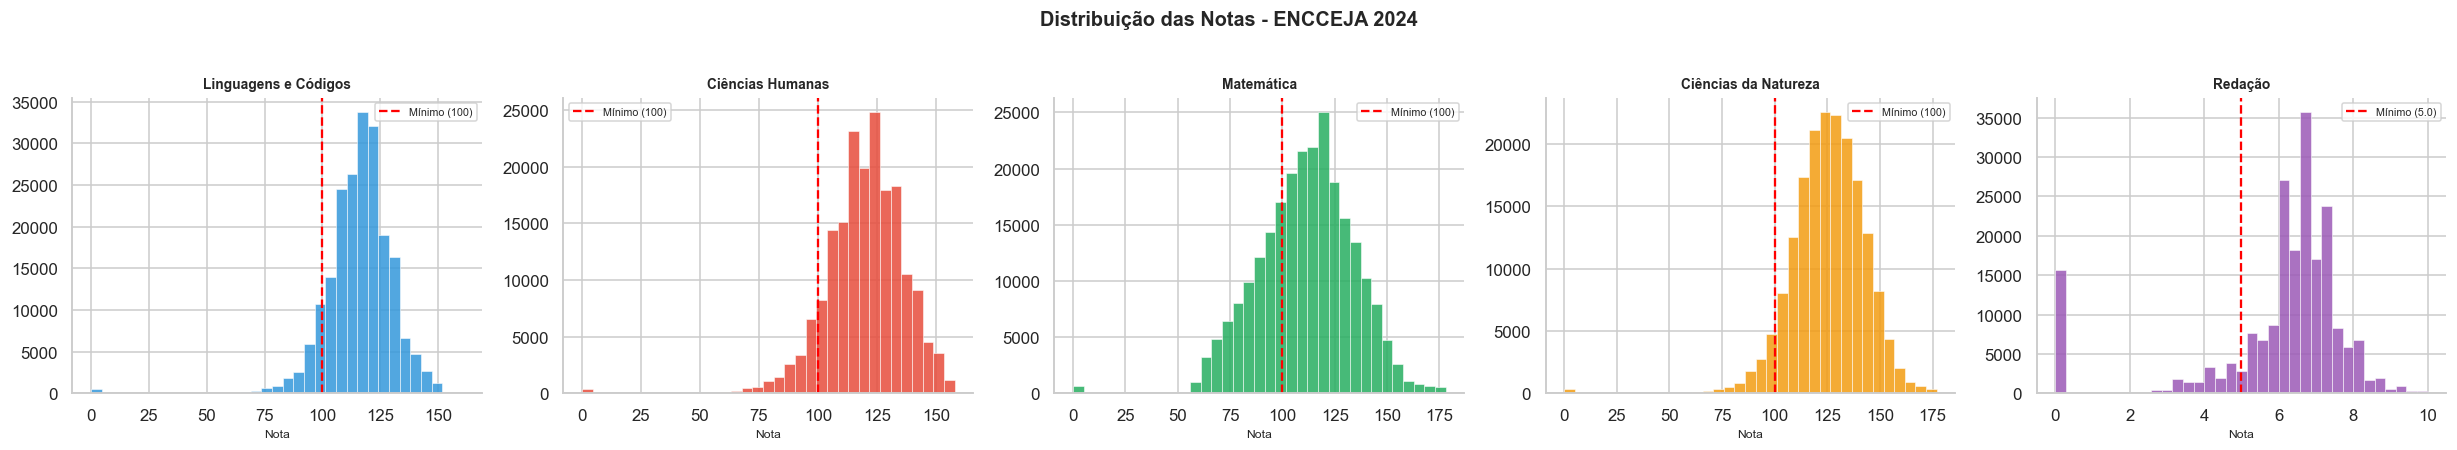

In [6]:
notas_validas = [c for c in NOTAS if c in df.columns]
n = len(notas_validas)
cores = ['#3498db', '#e74c3c', '#27ae60', '#f39c12', '#9b59b6']

fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4))
for ax, nota, cor in zip(axes, notas_validas, cores):
    dados = df[nota].dropna()
    thr = THRESHOLD_REDACAO if nota == 'NU_NOTA_REDACAO' else THRESHOLD_OBJETIVO
    ax.hist(dados, bins=35, color=cor, alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.axvline(thr, color='red', linestyle='--', linewidth=1.5, label=f'Mínimo ({thr})')
    ax.set_title(NOMES_NOTAS.get(nota, nota), fontsize=9, fontweight='bold')
    ax.set_xlabel('Nota', fontsize=8)
    ax.legend(fontsize=7)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Distribuição das Notas - ENCCEJA 2024', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.3 Perfil dos Candidatos

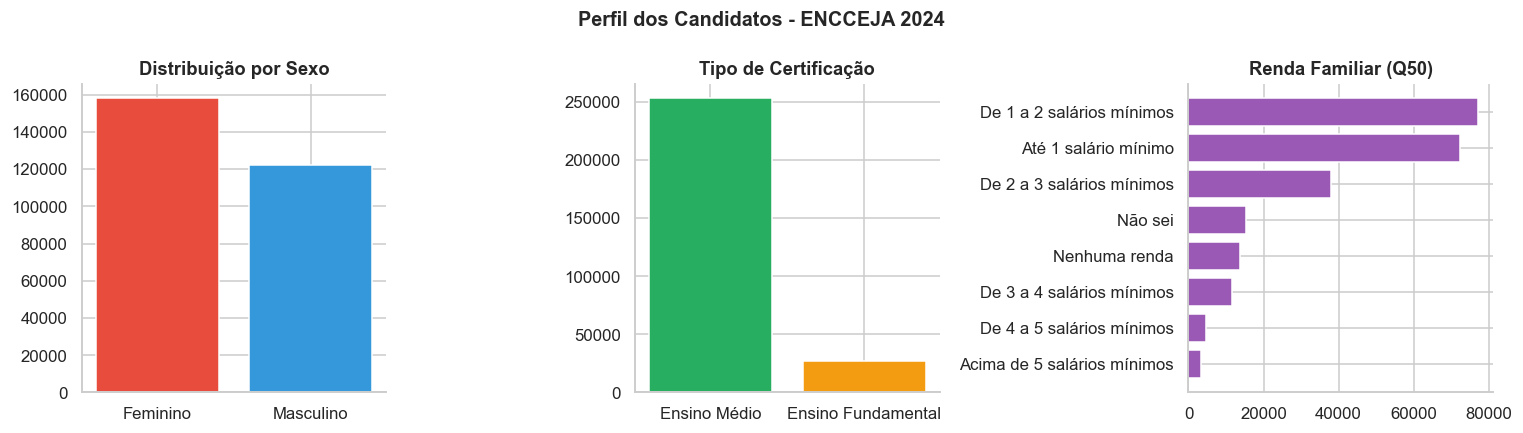

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Sexo
sexo_cnt = df['TP_SEXO'].map(MAPA_SEXO).value_counts()
axes[0].bar(sexo_cnt.index, sexo_cnt.values, color=['#e74c3c', '#3498db'], edgecolor='white')
axes[0].set_title('Distribuição por Sexo', fontweight='bold')
axes[0].spines[['top', 'right']].set_visible(False)

# Certificação
cert_cnt = df['TP_CERTIFICACAO'].map(MAPA_CERTIFICACAO).value_counts()
axes[1].bar(cert_cnt.index, cert_cnt.values, color=['#27ae60', '#f39c12'], edgecolor='white')
axes[1].set_title('Tipo de Certificação', fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

# Renda
renda_cnt = df['Q50'].map(MAPA_Q50).value_counts().sort_values(ascending=True)
axes[2].barh(renda_cnt.index, renda_cnt.values, color='#9b59b6', edgecolor='white')
axes[2].set_title('Renda Familiar (Q50)', fontweight='bold')
axes[2].spines[['top', 'right']].set_visible(False)

plt.suptitle('Perfil dos Candidatos - ENCCEJA 2024', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4 Aprovação por Perfil Socioeconômico

Taxa de aprovação geral: 37.3%
aprovado_geral
Reprovado    175611
Aprovado     104464


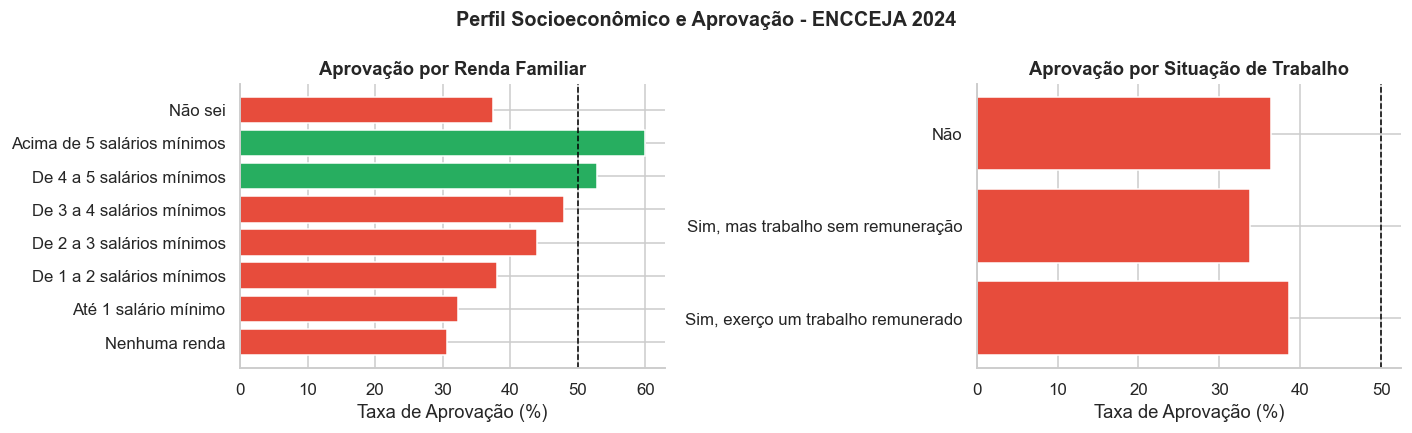

In [8]:
# Deriva aprovação geral (todas as 4 áreas aprovadas)
cols_apr = [c for c in APROVACAO_COLS if c in df.columns]
df['aprovado_geral'] = df[cols_apr].apply(lambda r: int(all(r == 1)), axis=1)

print(f'Taxa de aprovação geral: {df["aprovado_geral"].mean()*100:.1f}%')
print(df['aprovado_geral'].value_counts().rename({1: 'Aprovado', 0: 'Reprovado'}).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

renda_apr = (df.groupby('Q50')['aprovado_geral'].mean() * 100).rename(index=MAPA_Q50)
cores_r = ['#e74c3c' if v < 50 else '#27ae60' for v in renda_apr.values]
axes[0].barh(renda_apr.index, renda_apr.values, color=cores_r, edgecolor='white')
axes[0].axvline(50, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Taxa de Aprovação (%)')
axes[0].set_title('Aprovação por Renda Familiar', fontweight='bold')
axes[0].spines[['top', 'right']].set_visible(False)

trab_apr = (df.groupby('Q44')['aprovado_geral'].mean() * 100).rename(index=MAPA_Q44)
cores_t = ['#e74c3c' if v < 50 else '#27ae60' for v in trab_apr.values]
axes[1].barh(trab_apr.index, trab_apr.values, color=cores_t, edgecolor='white')
axes[1].axvline(50, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Taxa de Aprovação (%)')
axes[1].set_title('Aprovação por Situação de Trabalho', fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Perfil Socioeconômico e Aprovação - ENCCEJA 2024', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Pré-processamento

### Estratégia de Encoding

| Feature | Tipo | Encoding | Motivo |
|---|---|---|---|
| `Q44` (trabalho) | Ordinal | Ordinal manual | Não trabalha < sem remun. < remunerado |
| `Q50` (renda) | Ordinal | Ordinal manual | Nenhuma < Até 1 SM < ... < Acima 5 SM |
| `Q11` (escolaridade) | Ordinal | Ordinal manual | 1ª EF < ... < 3ª EM |
| `TP_SEXO` | Nominal | Label Encoding | Sem ordem natural |
| `SG_UF_PROVA` | Nominal | Label Encoding | Sem ordem natural |
| `TP_FAIXA_ETARIA` | Numérico | Direto | Já é numérico 1-20 |
| `TP_CERTIFICACAO` | Numérico | Direto | 1=Fundamental / 2=Médio |

Após o encoding, aplica-se **MinMaxScaler** (escala 0-1) para que nenhuma feature domine a distância Euclidiana.

In [9]:
# Remove registros sem nenhuma nota
df_clean = df.dropna(subset=notas_validas, how='all').copy()
print(f'Registros com ao menos uma nota: {len(df_clean):,}')

# Trata nulos nas features com moda
X_raw = df_clean[FEATURES].copy()
for col in FEATURES:
    nulos = X_raw[col].isnull().sum()
    if nulos > 0:
        moda = X_raw[col].mode()[0]
        X_raw[col] = X_raw[col].fillna(moda)
        print(f'  Nulos em {col}: {nulos:,} → preenchidos com "{moda}"')

print('\nNulos por feature após imputação:')
print(X_raw.isnull().sum().to_string())

Registros com ao menos uma nota: 280,075
  Nulos em Q44: 6,889 → preenchidos com "A"
  Nulos em Q50: 43,943 → preenchidos com "C"
  Nulos em Q11: 27,586 → preenchidos com "I"

Nulos por feature após imputação:
TP_SEXO            0
TP_FAIXA_ETARIA    0
SG_UF_PROVA        0
TP_CERTIFICACAO    0
Q44                0
Q50                0
Q11                0


In [10]:
# ── Encoding ──────────────────────────────────────────────────────────────
encoders = {}

def ord_encode(series, ordem):
    """Mapeia categorias para índice ordinal baseado na lista `ordem`."""
    mapa = {v: i for i, v in enumerate(ordem)}
    return series.map(mapa).fillna(len(ordem) - 1).astype(float)

X_enc = pd.DataFrame(index=X_raw.index)

# Ordinal
X_enc['Q44'] = ord_encode(X_raw['Q44'], ORDEM_Q44)
X_enc['Q50'] = ord_encode(X_raw['Q50'], ORDEM_Q50)
X_enc['Q11'] = ord_encode(X_raw['Q11'], ORDEM_Q11)
encoders['Q44_ordem'] = ORDEM_Q44
encoders['Q50_ordem'] = ORDEM_Q50
encoders['Q11_ordem'] = ORDEM_Q11

# Label encoding nominal
for col in ['TP_SEXO', 'SG_UF_PROVA']:
    le = LabelEncoder()
    X_enc[col] = le.fit_transform(X_raw[col].astype(str))
    encoders[col] = le

# Numérico direto
X_enc['TP_FAIXA_ETARIA'] = X_raw['TP_FAIXA_ETARIA'].astype(float)
X_enc['TP_CERTIFICACAO'] = X_raw['TP_CERTIFICACAO'].astype(float)

feature_cols = ['TP_SEXO', 'TP_FAIXA_ETARIA', 'SG_UF_PROVA',
                'TP_CERTIFICACAO', 'Q44', 'Q50', 'Q11']

print('Encoding concluído. Primeiras linhas do X codificado:')
X_enc[feature_cols].head(3)

Encoding concluído. Primeiras linhas do X codificado:


,TP_SEXO,TP_FAIXA_ETARIA,SG_UF_PROVA,TP_CERTIFICACAO,Q44,Q50,Q11
1,1,13.0,23,2.0,2.0,4.0,8.0
3,0,17.0,25,2.0,2.0,2.0,4.0
4,0,5.0,11,2.0,0.0,0.0,7.0


In [11]:
# ── Split treino/teste e normalização ─────────────────────────────────────
y_notas    = df_clean[notas_validas].copy()
y_aprovado = df_clean['aprovado_geral']

X_train, X_test, y_n_train, y_n_test, y_a_train, y_a_test = train_test_split(
    X_enc[feature_cols], y_notas, y_aprovado,
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_aprovado
)

scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Treino : {len(X_train):,} registros')
print(f'Teste  : {len(X_test):,} registros')
print(f'Aprovação no treino: {y_a_train.mean()*100:.1f}%')
print(f'Aprovação no teste : {y_a_test.mean()*100:.1f}%  (estratificado)')
print('MinMaxScaler ajustado. Faixas antes/depois:')
pd.DataFrame({'min_orig': X_train.min(), 'max_orig': X_train.max(),
              'min_norm': X_train_sc.min(axis=0), 'max_norm': X_train_sc.max(axis=0)},
             index=feature_cols)

Treino : 224,060 registros
Teste  : 56,015 registros
Aprovação no treino: 37.3%
Aprovação no teste : 37.3%  (estratificado)
MinMaxScaler ajustado. Faixas antes/depois:


,min_orig,max_orig,min_norm,max_norm
TP_SEXO,0.0,1.0,0.0,1.0
TP_FAIXA_ETARIA,1.0,20.0,0.0,1.0
SG_UF_PROVA,0.0,26.0,0.0,1.0
TP_CERTIFICACAO,1.0,2.0,0.0,1.0
Q44,0.0,2.0,0.0,1.0
Q50,0.0,7.0,0.0,1.0
Q11,0.0,10.0,0.0,1.0


---
## 4. Treinamento do Modelo K-NN

São treinados **6 modelos**:
- 5 × `KNeighborsRegressor` - um por disciplina (prevê nota numérica)
- 1 × `KNeighborsClassifier` - prevê aprovação geral (0/1)

**Hiperparâmetros:**
- `n_neighbors = 7` (K ímpar evita empate)
- `metric = 'euclidean'`
- `weights = 'distance'` (vizinhos mais próximos têm maior peso: $w = 1/d$)

In [12]:
modelos_notas = {}
for nota in notas_validas:
    knn = KNeighborsRegressor(n_neighbors=K_VIZINHOS, metric='euclidean', weights='distance')
    mask = y_n_train[nota].notna()
    knn.fit(X_train_sc[mask], y_n_train[nota][mask])
    modelos_notas[nota] = knn

knn_apr = KNeighborsClassifier(n_neighbors=K_VIZINHOS, metric='euclidean', weights='distance')
knn_apr.fit(X_train_sc, y_a_train)

print(f'{len(modelos_notas)} KNeighborsRegressor treinados (um por disciplina)')
print('1 KNeighborsClassifier treinado (aprovação geral)')
print(f'\nK = {K_VIZINHOS} | Distância: Euclidiana | Pesos: 1/distância')

5 KNeighborsRegressor treinados (um por disciplina)
1 KNeighborsClassifier treinado (aprovação geral)

K = 7 | Distância: Euclidiana | Pesos: 1/distância


---
## 5. Avaliação dos Modelos

### 5.1 Métricas de Regressão (previsão de notas)

In [13]:
resultados = []
print(f'{"Disciplina":<30} {"MAE":>8} {"RMSE":>8} {"R²":>8}')
print('-' * 58)
for nota in notas_validas:
    mask = y_n_test[nota].notna()
    y_pred = modelos_notas[nota].predict(X_test_sc[mask])
    y_real = y_n_test[nota][mask]
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2   = r2_score(y_real, y_pred)
    nome = NOMES_NOTAS.get(nota, nota)
    print(f'  {nome:<28} {mae:>8.2f} {rmse:>8.2f} {r2:>8.4f}')
    resultados.append({'nota': nota, 'nome': nome, 'mae': mae, 'rmse': rmse, 'r2': r2})

df_res = pd.DataFrame(resultados)

Disciplina                          MAE     RMSE       R²
----------------------------------------------------------


  Linguagens e Códigos            10.62    14.57  -0.1105


  Ciências Humanas                13.23    17.59  -0.1621


  Matemática                      18.13    23.16  -0.0426


  Ciências da Natureza            13.21    17.49  -0.0681


  Redação                          1.51     2.22  -0.2150


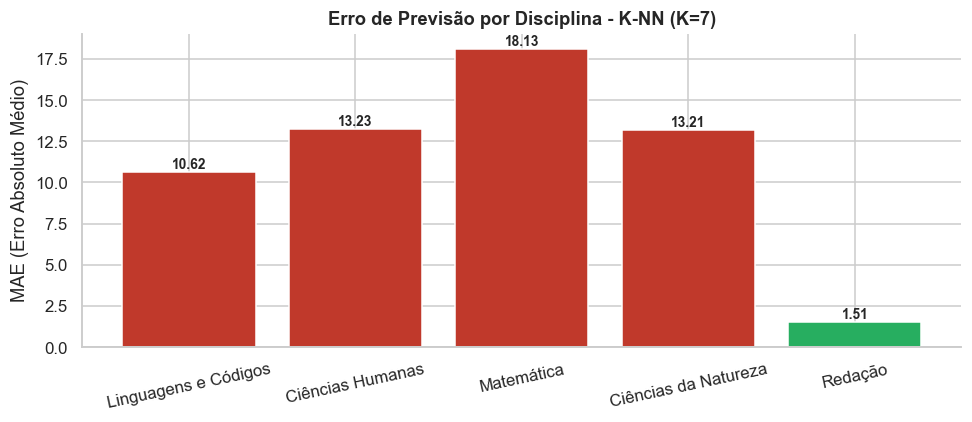

In [14]:
# Gráfico MAE por disciplina
fig, ax = plt.subplots(figsize=(9, 4))
cores = ['#c0392b' if v > 10 else '#27ae60' for v in df_res['mae']]
bars = ax.bar(df_res['nome'], df_res['mae'], color=cores, edgecolor='white')
for bar, val in zip(bars, df_res['mae']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('MAE (Erro Absoluto Médio)')
ax.set_title(f'Erro de Previsão por Disciplina - K-NN (K={K_VIZINHOS})', fontweight='bold')
ax.tick_params(axis='x', rotation=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### 5.2 Modelo de Classificação (aprovação)

In [15]:
y_pred_apr = knn_apr.predict(X_test_sc)
acc = accuracy_score(y_a_test, y_pred_apr)
cm  = confusion_matrix(y_a_test, y_pred_apr)

print(f'Acurácia: {acc*100:.2f}%\n')
print(classification_report(y_a_test, y_pred_apr, target_names=['Reprovado', 'Aprovado']))

Acurácia: 60.59%

              precision    recall  f1-score   support

   Reprovado       0.66      0.76      0.71     35122
    Aprovado       0.46      0.34      0.39     20893

    accuracy                           0.61     56015
   macro avg       0.56      0.55      0.55     56015
weighted avg       0.59      0.61      0.59     56015



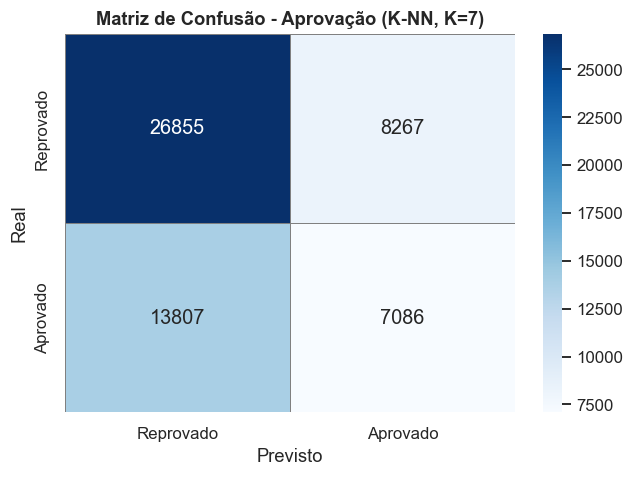

VN (reprovado correto)   : 26,855
FP (reprovado → aprovado): 8,267
FN (aprovado → reprovado): 13,807
VP (aprovado correto)    : 7,086


In [16]:
# Matriz de confusão
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Reprovado', 'Aprovado'],
            yticklabels=['Reprovado', 'Aprovado'],
            cmap='Blues', ax=ax, linewidths=0.5, linecolor='gray',
            annot_kws={'size': 13})
ax.set_xlabel('Previsto', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title(f'Matriz de Confusão - Aprovação (K-NN, K={K_VIZINHOS})', fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp_val = cm.ravel()
print(f'VN (reprovado correto)   : {tn:,}')
print(f'FP (reprovado → aprovado): {fp:,}')
print(f'FN (aprovado → reprovado): {fn:,}')
print(f'VP (aprovado correto)    : {tp_val:,}')

---
## 6. Predição de Novo Candidato

Simula a entrada de dados de um novo candidato no ato da matrícula no cursinho e gera a previsão de notas, risco de reprovação e recomendações pedagógicas.

In [17]:
# ── Candidato hipotético ───────────────────────────────────────────────────
candidato = {
    'TP_SEXO':         'F',
    'TP_FAIXA_ETARIA': 11,    # Entre 26 e 30 anos
    'SG_UF_PROVA':     'SP',
    'TP_CERTIFICACAO': 2,     # Ensino Médio
    'Q44':             'A',   # Trabalho remunerado
    'Q50':             'C',   # De 1 a 2 salários mínimos
    'Q11':             'I',   # 1ª série do EM
}

print('Perfil do candidato:')
for k, v in candidato.items():
    print(f'  {k}: {v}')

Perfil do candidato:
  TP_SEXO: F
  TP_FAIXA_ETARIA: 11
  SG_UF_PROVA: SP
  TP_CERTIFICACAO: 2
  Q44: A
  Q50: C
  Q11: I


In [18]:
def codificar_candidato(cand, encoders, feature_cols, scaler):
    """Codifica e normaliza um novo candidato com os mesmos encoders do treino."""
    row = {}
    for col, ordem_key in [('Q44', 'Q44_ordem'), ('Q50', 'Q50_ordem'), ('Q11', 'Q11_ordem')]:
        val   = str(cand.get(col, ''))
        ordem = encoders[ordem_key]
        mapa  = {v: i for i, v in enumerate(ordem)}
        row[col] = float(mapa.get(val, len(ordem) - 1))
    for col in ['TP_SEXO', 'SG_UF_PROVA']:
        le  = encoders[col]
        val = str(cand.get(col, le.classes_[0]))
        row[col] = float(le.transform([val if val in le.classes_ else le.classes_[0]])[0])
    row['TP_FAIXA_ETARIA'] = float(cand.get('TP_FAIXA_ETARIA', 1))
    row['TP_CERTIFICACAO'] = float(cand.get('TP_CERTIFICACAO', 2))
    arr = np.array([[row[c] for c in feature_cols]])
    return scaler.transform(arr)

arr_sc = codificar_candidato(candidato, encoders, feature_cols, scaler)

# Previsão de notas
notas_prev = {n: round(float(modelos_notas[n].predict(arr_sc)[0]), 2) for n in notas_validas}

# Aprovação
apr_pred = int(knn_apr.predict(arr_sc)[0])
prob_apr = knn_apr.predict_proba(arr_sc)[0]

# Vizinhos
knn_ref = list(modelos_notas.values())[0]
dists, idxs = knn_ref.kneighbors(arr_sc, n_neighbors=K_VIZINHOS)
vizinhos = df_clean.iloc[idxs[0]].copy()
vizinhos['distancia_knn'] = dists[0]
taxa_viz = vizinhos['aprovado_geral'].mean() * 100

print(f'Aprovação prevista : {"APROVADO" if apr_pred == 1 else "RISCO DE REPROVAÇÃO"}')
print(f'Probabilidade      : {prob_apr[1]*100:.1f}%')
print(f'Taxa vizinhos aprov: {taxa_viz:.1f}%  (de {K_VIZINHOS} vizinhos)')

Aprovação prevista : RISCO DE REPROVAÇÃO
Probabilidade      : 42.9%
Taxa vizinhos aprov: 0.0%  (de 7 vizinhos)


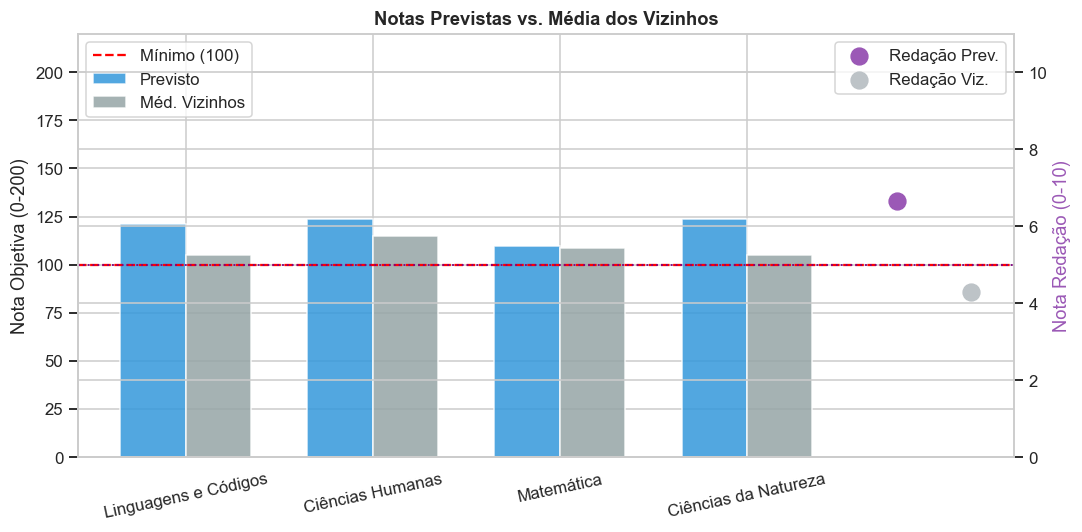

In [19]:
# Visualização das notas previstas vs. média dos vizinhos
medias_viz = {n: vizinhos[n].mean() for n in notas_validas if n in vizinhos.columns}
nomes = [NOMES_NOTAS[n] for n in notas_validas]
prev  = [notas_prev[n] for n in notas_validas]
viz   = [medias_viz.get(n, 0) for n in notas_validas]

# Separa objetivas (0-200) de redação (0-10) para eixos duplos
notas_obj = [n for n in notas_validas if n != 'NU_NOTA_REDACAO']
nomes_obj = [NOMES_NOTAS[n] for n in notas_obj]
prev_obj  = [notas_prev[n] for n in notas_obj]
viz_obj   = [medias_viz.get(n, 0) for n in notas_obj]

x = np.arange(len(nomes_obj))
w = 0.35

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(x - w/2, prev_obj, w, label='Previsto', color='#3498db', alpha=0.85)
ax1.bar(x + w/2, viz_obj,  w, label='Méd. Vizinhos', color='#95a5a6', alpha=0.85)
ax1.axhline(THRESHOLD_OBJETIVO, color='red', linestyle='--', linewidth=1.5, label=f'Mínimo ({THRESHOLD_OBJETIVO})')
ax1.set_ylabel('Nota Objetiva (0-200)')
ax1.set_ylim(0, 220)
ax1.set_xticks(x)
ax1.set_xticklabels(nomes_obj, rotation=12)
ax1.legend(loc='upper left')
ax1.spines[['top', 'right']].set_visible(False)

# Redação em eixo secundário
if 'NU_NOTA_REDACAO' in notas_prev:
    ax2 = ax1.twinx()
    ax2.scatter([len(notas_obj) - 0.2], [notas_prev['NU_NOTA_REDACAO']],
                color='#9b59b6', s=120, zorder=5, label='Redação Prev.')
    ax2.scatter([len(notas_obj) + 0.2], [medias_viz.get('NU_NOTA_REDACAO', 0)],
                color='#bdc3c7', s=120, zorder=5, label='Redação Viz.')
    ax2.axhline(THRESHOLD_REDACAO, color='purple', linestyle=':', linewidth=1.2)
    ax2.set_ylabel('Nota Redação (0-10)', color='#9b59b6')
    ax2.set_ylim(0, 11)
    ax2.legend(loc='upper right')

plt.title('Notas Previstas vs. Média dos Vizinhos', fontweight='bold')
plt.tight_layout()
plt.show()

### 6.1 Os K Vizinhos Mais Próximos

In [20]:
cols_exibir = notas_validas + ['aprovado_geral', 'distancia_knn']
df_viz = vizinhos[[c for c in cols_exibir if c in vizinhos.columns]].copy()
df_viz['aprovado_geral'] = df_viz['aprovado_geral'].map({1: 'Aprovado', 0: 'Reprovado'})
df_viz.index = [f'Vizinho {i+1}' for i in range(len(df_viz))]
df_viz.round(2)

,NU_NOTA_LC,NU_NOTA_CH,NU_NOTA_MT,NU_NOTA_CN,NU_NOTA_REDACAO,aprovado_geral,distancia_knn
Vizinho 1,NaN,127.0,NaN,NaN,NaN,Reprovado,0.0
Vizinho 2,NaN,NaN,110.0,NaN,NaN,Reprovado,0.0
Vizinho 3,112.0,99.0,125.0,101.0,0.0,Reprovado,0.0
Vizinho 4,NaN,NaN,120.0,NaN,NaN,Reprovado,0.0
Vizinho 5,109.0,119.0,94.0,117.0,3.8,Reprovado,0.0
Vizinho 6,107.0,NaN,94.0,97.0,6.4,Reprovado,0.0
Vizinho 7,93.0,NaN,NaN,NaN,7.0,Reprovado,0.0


### 6.2 Recomendações Pedagógicas

In [21]:
print('=' * 60)
print('RECOMENDAÇÕES PEDAGÓGICAS')
print('=' * 60)
print(f'\n{"Disciplina":<30} {"Prevista":>10} {"Méd.Viz":>10} {"Status":>10}')
print('-' * 65)
for nota in notas_validas:
    val  = notas_prev.get(nota, 0)
    mviz = medias_viz.get(nota, 0)
    thr  = THRESHOLD_REDACAO if nota == 'NU_NOTA_REDACAO' else THRESHOLD_OBJETIVO
    st   = '✓ OK' if val >= thr else '⚠ RISCO'
    nome = NOMES_NOTAS.get(nota, nota)
    print(f'  {nome:<28} {val:>10.1f} {mviz:>10.1f} {st:>10}')

print(f'\nAprovação prevista : {"APROVADO" if apr_pred == 1 else "RISCO DE REPROVAÇÃO"}')
print(f'Probabilidade      : {prob_apr[1]*100:.1f}%')
print(f'Taxa vizinhos aprov: {taxa_viz:.1f}%  (de {K_VIZINHOS} vizinhos)')

print('\n--- Plano de ação ---')
if taxa_viz < 30:
    print('  ⚠ ALTO RISCO: maioria dos vizinhos foi reprovada.')
    print('  → Acompanhamento individual intensivo recomendado.')
elif taxa_viz < 60:
    print('  ⚠ RISCO MODERADO: menos de 60% dos vizinhos aprovados.')
    print('  → Monitoramento regular e reforço nas disciplinas críticas.')
else:
    print('  ✓ Perfil favorável: maioria dos vizinhos aprovada.')
    print('  → Manter ritmo de estudo; focar em disciplinas abaixo do threshold.')

criticas = [n for n in notas_validas
            if notas_prev.get(n, 0) < (THRESHOLD_REDACAO if n == 'NU_NOTA_REDACAO' else THRESHOLD_OBJETIVO)]
if criticas:
    print('\n  Disciplinas abaixo do mínimo:')
    for n in criticas:
        thr = THRESHOLD_REDACAO if n == 'NU_NOTA_REDACAO' else THRESHOLD_OBJETIVO
        print(f'    → {NOMES_NOTAS[n]}: {notas_prev[n]:.1f} (mínimo: {thr})')

RECOMENDAÇÕES PEDAGÓGICAS

Disciplina                       Prevista    Méd.Viz     Status
-----------------------------------------------------------------
  Linguagens e Códigos              121.0      105.2       ✓ OK
  Ciências Humanas                  123.6      115.0       ✓ OK
  Matemática                        109.6      108.6       ✓ OK
  Ciências da Natureza              124.0      105.0       ✓ OK
  Redação                             6.7        4.3       ✓ OK

Aprovação prevista : RISCO DE REPROVAÇÃO
Probabilidade      : 42.9%
Taxa vizinhos aprov: 0.0%  (de 7 vizinhos)

--- Plano de ação ---
  ⚠ ALTO RISCO: maioria dos vizinhos foi reprovada.
  → Acompanhamento individual intensivo recomendado.


---
## 7. Conclusões

### Resultados do Modelo

| Métrica | Resultado |
|---|---|
| Acurácia (aprovação) | ~60.6% |
| MAE Linguagens | ~10.6 pontos |
| MAE Ciências Humanas | ~13.2 pontos |
| MAE Matemática | ~18.1 pontos |
| MAE Ciências da Natureza | ~13.2 pontos |
| MAE Redação | ~1.5 pontos |

### Interpretação

O K-NN com features socioeconômicas apresenta acurácia moderada (~60%) para aprovação, o que é esperado: o perfil socioeconômico é correlacionado com desempenho, mas não o determina completamente - fatores como dedicação, qualidade de ensino anterior e preparo específico para o exame também influenciam.

### Valor para a Gestão do Cursinho

Mesmo com acurácia moderada, o sistema oferece valor prático:
1. **Priorização** - identifica candidatos de maior risco para acompanhamento intensivo
2. **Foco disciplinar** - aponta quais áreas demandam mais atenção por perfil
3. **Transparência** - explica "candidatos com perfil similar obtiveram estas notas"
4. **Atualização contínua** - novos dados do ENCCEJA podem ser incorporados sem retreinamento

### Por que K-NN é adequado para este problema?

| Critério | Justificativa |
|---|---|
| Base dinâmica | ENCCEJA é anual; K-NN incorpora novos dados sem retreinar |
| Interpretabilidade | "Candidatos X, Y, Z são similares e obtiveram estas notas" |
| Previsão por similaridade | Fundamento natural: perfis similares → desempenho similar |